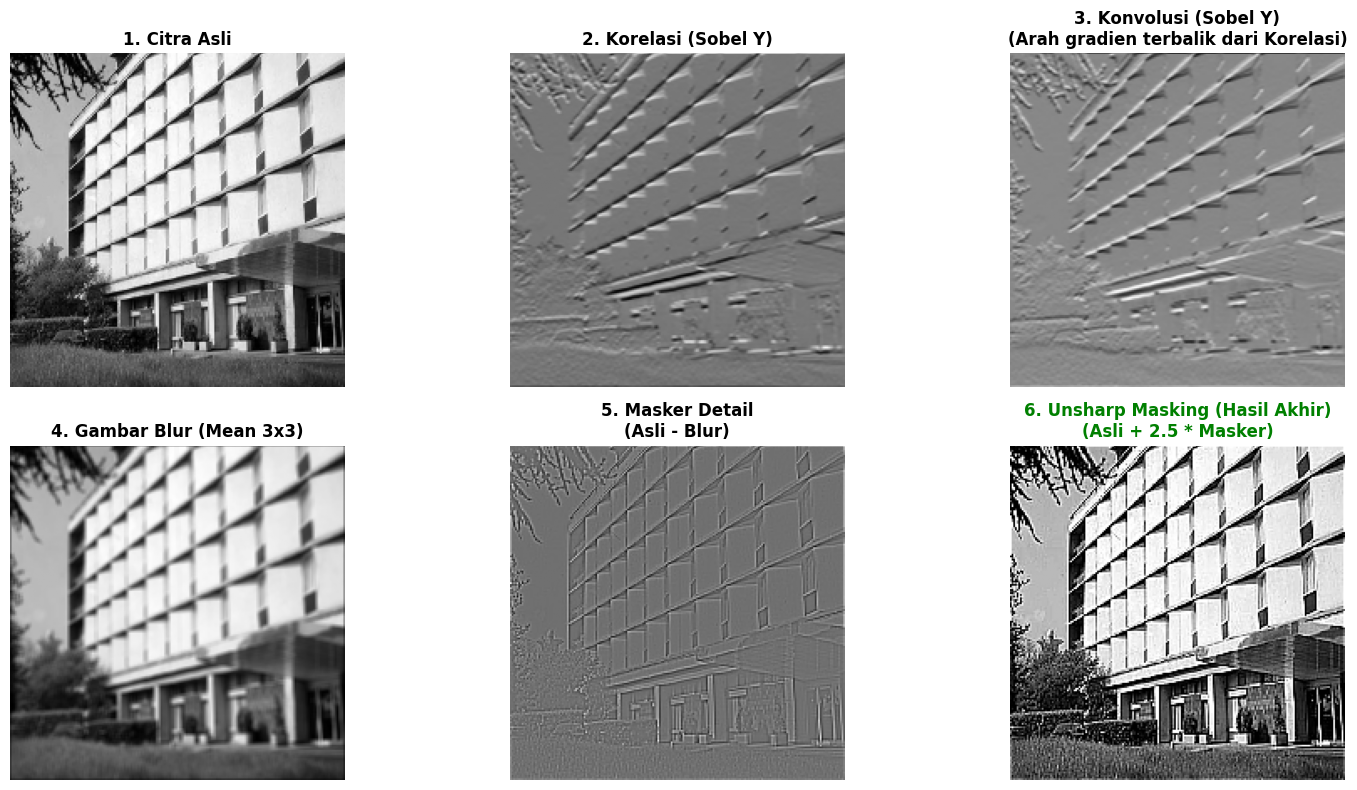

In [1]:
# ======================================================================
# LAB PERTEMUAN 3b: SPATIAL FILTERING DARI NOL (FROM SCRATCH)
# Menggunakan Library Minimal (Hanya NumPy dan Matplotlib)
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import cv2 # HANYA digunakan untuk membaca dan resize gambar di awal

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA (Gunakan gambar kecil agar loop manual tidak terlalu lama)
# ----------------------------------------------------------------------
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/building.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img_asli = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
img_asli = cv2.resize(img_asli, (200, 200)) # Diperkecil menjadi 200x200
img_float = img_asli.astype(np.float32) # Ubah ke float untuk perhitungan desimal

# ----------------------------------------------------------------------
# 2. IMPLEMENTASI MATEMATIS: KORELASI & KONVOLUSI
# ----------------------------------------------------------------------
# Rumus Korelasi: G(i,j) = sum( H(u,v) * F(i+u, j+v) )
# Rumus Konvolusi: G(i,j) = sum( H(u,v) * F(i-u, j-v) ) -> Ekivalen dengan memutar kernel 180 derajat.

def operasi_spasial_manual(image, kernel, mode='korelasi'):
    # Ambil ukuran citra dan kernel
    tinggi_img, lebar_img = image.shape
    k_tinggi, k_lebar = kernel.shape

    # Hitung ukuran padding (setengah dari ukuran kernel)
    pad_h = k_tinggi // 2
    pad_w = k_lebar // 2

    # Buat kanvas kosong dengan bingkai (Zero Padding)
    img_padded = np.zeros((tinggi_img + (2 * pad_h), lebar_img + (2 * pad_w)), dtype=np.float32)
    # Sisipkan gambar asli ke tengah kanvas padding
    img_padded[pad_h:pad_h+tinggi_img, pad_w:pad_w+lebar_img] = image

    # Siapkan matriks kosong untuk hasil akhir
    output = np.zeros_like(image)

    # Jika mode Konvolusi, putar kernel 180 derajat (Flip Vertikal & Horizontal)
    if mode == 'konvolusi':
        kernel = np.flipud(np.fliplr(kernel))

    # PROSES SLIDING WINDOW (Geser matriks dari sudut kiri atas ke kanan bawah)
    for i in range(tinggi_img):
        for j in range(lebar_img):
            # Potong area gambar sebesar ukuran kernel (Patching)
            patch = img_padded[i : i + k_tinggi, j : j + k_lebar]

            # Perkalian elemen per elemen (H * F) lalu dijumlahkan (sum)
            hasil_pixel = np.sum(patch * kernel)

            # Simpan hasil ke matriks output
            output[i, j] = hasil_pixel

    return output

# ----------------------------------------------------------------------
# 3. MEMBUAT KERNEL SECARA MANUAL
# ----------------------------------------------------------------------
# A. Mean Filter (3x3) -> Menjumlahkan 9 piksel, dibagi 9
kernel_mean = np.array([[1/9, 1/9, 1/9],
                        [1/9, 1/9, 1/9],
                        [1/9, 1/9, 1/9]])

# B. Sobel Horizontal (Mendeteksi perubahan vertikal)
# Perhatikan bahwa kernel ini TIDAK simetris.
kernel_sobel_y = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

# ----------------------------------------------------------------------
# 4. EKSEKUSI PEMBUKTIAN: KORELASI vs KONVOLUSI
# ----------------------------------------------------------------------
# Menggunakan kernel Sobel yang tidak simetris untuk melihat perbedaannya
hasil_korelasi = operasi_spasial_manual(img_float, kernel_sobel_y, mode='korelasi')
hasil_konvolusi = operasi_spasial_manual(img_float, kernel_sobel_y, mode='konvolusi')

# ----------------------------------------------------------------------
# 5. MATEMATIKA UNSHARP MASKING (Penajaman)
# ----------------------------------------------------------------------
# Rumus 1: Buat gambar blur
img_blur = operasi_spasial_manual(img_float, kernel_mean, mode='korelasi')

# Rumus 2: Cari Masker Detail (Gambar Asli - Gambar Blur)
mask_detail = img_float - img_blur

# Rumus 3: Tambahkan Masker ke Gambar Asli (I_sharp = I + k * Mask)
k = 2.5 # Faktor penguatan penajaman (semakin besar semakin tajam/kasar)
img_tajam = img_float + (k * mask_detail)

# Memastikan nilai tidak ada yang melebihi batas 0-255 (Clipping)
img_tajam = np.clip(img_tajam, 0, 255).astype(np.uint8)

# ----------------------------------------------------------------------
# 6. VISUALISASI HASIL (MATPLOTLIB)
# ----------------------------------------------------------------------
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title("1. Citra Asli", fontweight='bold')
plt.imshow(img_asli, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Korelasi (Sobel Y)", fontweight='bold')
# Tepi atas terang, tepi bawah gelap
plt.imshow(hasil_korelasi, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("3. Konvolusi (Sobel Y)\n(Arah gradien terbalik dari Korelasi)", fontweight='bold')
# Tepi atas gelap, tepi bawah terang karena kernel diputar 180 derajat
plt.imshow(hasil_konvolusi, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("4. Gambar Blur (Mean 3x3)", fontweight='bold')
plt.imshow(np.clip(img_blur, 0, 255).astype(np.uint8), cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("5. Masker Detail\n(Asli - Blur)", fontweight='bold')
plt.imshow(mask_detail, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("6. Unsharp Masking (Hasil Akhir)\n(Asli + 2.5 * Masker)", fontweight='bold', color='green')
plt.imshow(img_tajam, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()